The dataset contains 5,000 users randomly assigned to either **Group A (Control)** or **Group B (Treatment)**.- page views : talk about number of pages user visit
- Time Spent : talk about how much time user spent in our website
- Conversion : talk about did the user did any purchase or not
- Device : talk of what system is used
- Location : what is the location of the user
- Group : A(control group) = when website background is white, B(Treatement group) = when website background is dark

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('ab_testing.csv')
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [3]:
df.shape

(5000, 7)

In [4]:
df.isnull().sum()

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   User ID     5000 non-null   int64
 1   Group       5000 non-null   str  
 2   Page Views  5000 non-null   int64
 3   Time Spent  5000 non-null   int64
 4   Conversion  5000 non-null   str  
 5   Device      5000 non-null   str  
 6   Location    5000 non-null   str  
dtypes: int64(3), str(4)
memory usage: 273.6 KB


In [6]:
df.dtypes

User ID       int64
Group           str
Page Views    int64
Time Spent    int64
Conversion      str
Device          str
Location        str
dtype: object

In [7]:
df.describe()

,User ID,Page Views,Time Spent
count,5000.000000,5000.000000,5000.000000
mean,14925.159000,7.537600,242.512600
std,2869.153773,4.022465,118.254153
min,10001.000000,1.000000,40.000000
25%,12456.250000,4.000000,137.000000
50%,14858.500000,8.000000,243.000000
75%,17379.750000,11.000000,346.000000
max,19995.000000,14.000000,449.000000


In [8]:
df.describe(include = ["object", "string"])

,Group,Conversion,Device,Location
count,5000,5000,5000,5000
unique,2,2,2,4
top,A,No,Desktop,Scotland
freq,2519,4515,2538,1281


### Well this show that dosent matter group A or B, both are spending almost equal amount of time on our website

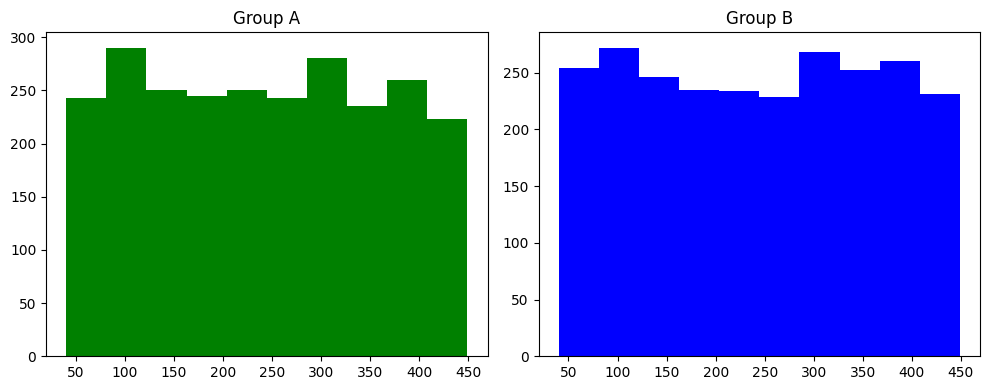

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df[df['Group'] == 'A']['Time Spent'], color='green')
ax[0].set_title('Group A')

ax[1].hist(df[df['Group'] == 'B']['Time Spent'], color='blue')
ax[1].set_title('Group B')

plt.tight_layout()
plt.show()

In [10]:
Converse = df[df['Conversion'] == 'Yes']

sale = Converse.groupby('Group')['Time Spent'].sum()
sale

Group
A    33373
B    84613
Name: Time Spent, dtype: int64

### Now the box plot will be showing the sales happen for A and B group

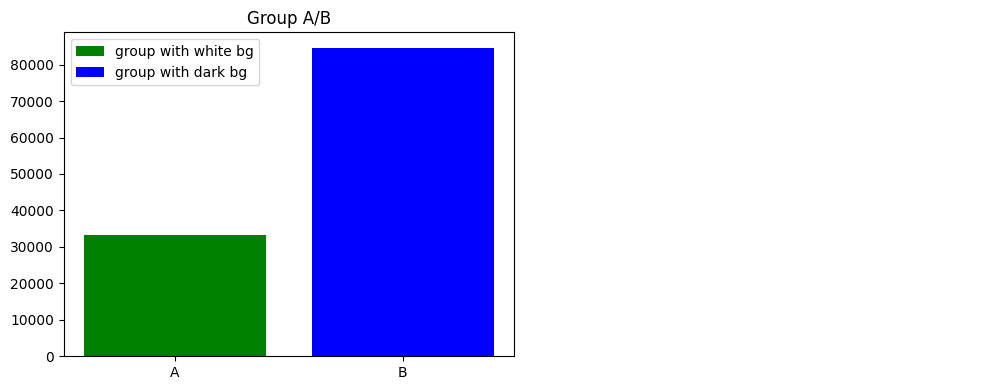

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].bar(sale.index[0], sale.values[0], color='green', label = 'group with white bg')
ax[0].bar(sale.index[1], sale.values[1], color='blue', label = 'group with dark bg')

ax[0].set_title('Group A/B')
ax[1].axis('off')

ax[0].legend()
plt.tight_layout()
plt.show()

### Bar chart is showing, that conversion of Group B (*Dark Theme*) is significant higher then Group A (*Light Theme*)

### Which device have high conversion and which have low conversion ?

In [12]:
mobile = df[df['Device'] == 'Mobile']
desktop = df[df['Device'] == 'Desktop']

mobile = mobile[mobile['Conversion'] == 'Yes']
desktop = desktop[desktop['Conversion'] == 'Yes']

mobile_conversion = mobile.groupby('Group').size()
desktop_conversion = desktop.groupby('Group').size()


In [13]:
mobileSales = pd.DataFrame(mobile_conversion).reset_index()
mobileSales = mobileSales.rename(columns={0: 'Mobile_Conversions'})

mobileSales

,Group,Mobile_Conversions
0,A,63
1,B,169


In [14]:
desktopSales = pd.DataFrame(desktop_conversion).reset_index()
desktopSales = desktopSales.rename(columns={0: 'Desktop_Conversions'})

desktopSales

,Group,Desktop_Conversions
0,A,73
1,B,180


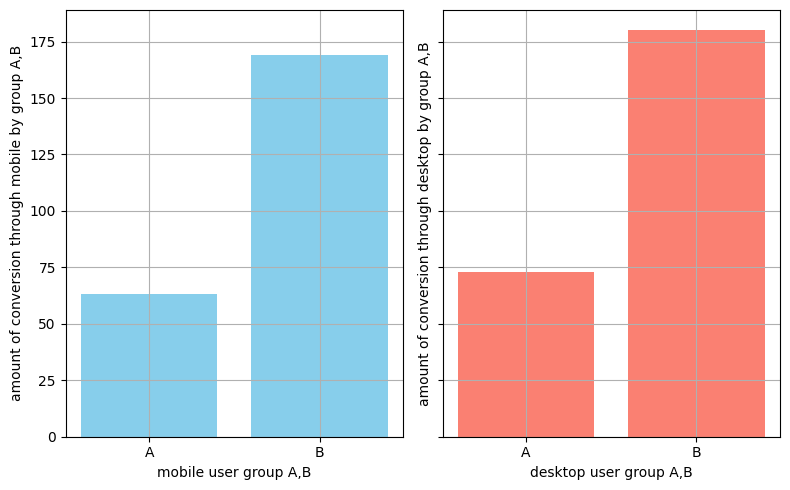

In [15]:
fig, ax = plt.subplots(1,2, figsize = (8,5), sharey = True)

ax[0].bar(mobileSales['Group'], mobileSales['Mobile_Conversions'], color = 'skyblue')
ax[0].set_xlabel('mobile user group A,B')
ax[0].set_ylabel('amount of conversion through mobile by group A,B')

ax[1].bar(desktopSales['Group'], desktopSales['Desktop_Conversions'], color = 'salmon')
ax[1].set_xlabel('desktop user group A,B')
ax[1].set_ylabel('amount of conversion through desktop by group A,B')

ax[0].grid(True)
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Definately the dark screen is showing more positive conversion
- it does not matter if the user is on mobile or desktop
- white screen show less conversion
- dark screen show more conversion

In [16]:
category_df = pd.merge(mobileSales, desktopSales, on='Group', how='outer').fillna(0)
category_df

,Group,Mobile_Conversions,Desktop_Conversions
0,A,63,73
1,B,169,180


In [17]:
location = pd.crosstab(df['Location'], df['Device'])
location['Mobile'].values

array([625, 600, 627, 610])

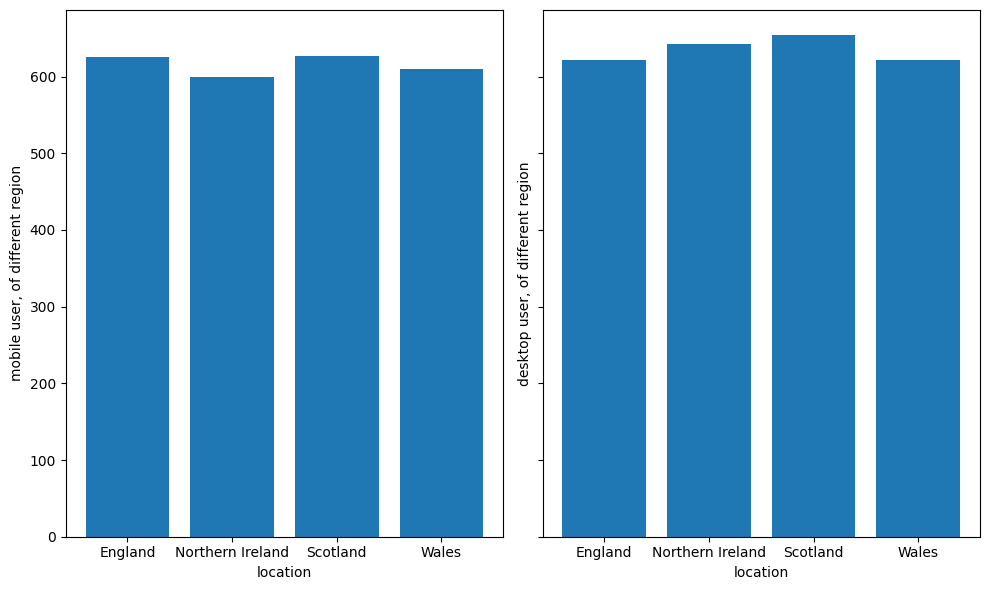

In [18]:
fig, ax = plt.subplots(1,2, figsize=(10,6), sharey = True)

ax[0].bar(location.index, location['Mobile'].values)
ax[0].set_xlabel('location')
ax[0].set_ylabel('mobile user, of different region')

ax[1].bar(location.index, location['Desktop'].values)
ax[1].set_xlabel('location')
ax[1].set_ylabel('desktop user, of different region')

plt.tight_layout()
plt.show()

## well region wise there is no such significance in usage of our website nither form mobile or from desktop.
- mobile user and desktop user have almost the same amount of users


## Lets check if there is any specific device that is been causing more conversions

In [19]:
conv_location = pd.crosstab(df[df['Conversion'] == 'Yes']['Location'], df['Device'])
conv_location

Device,Desktop,Mobile
Location,,
England,74,62
Northern Ireland,53,50
Scotland,62,63
Wales,64,57


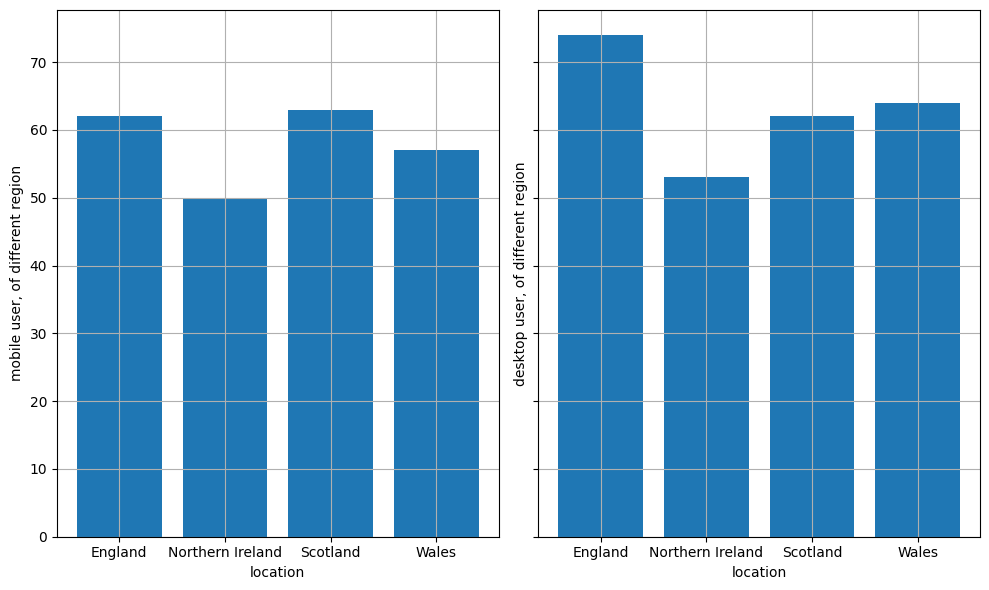

In [20]:
fig, ax = plt.subplots(1,2, figsize=(10,6), sharey = True)

ax[0].bar(conv_location.index, conv_location['Mobile'].values)
ax[0].set_xlabel('location')
ax[0].set_ylabel('mobile user, of different region')

ax[1].bar(conv_location.index, conv_location['Desktop'].values)
ax[1].set_xlabel('location')
ax[1].set_ylabel('desktop user, of different region')

ax[0].grid(True)
ax[1].grid(True)

plt.tight_layout()
plt.show()

England, Northern Ireland, and Wales show more little more conversion form desktop then form mobile

In [21]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


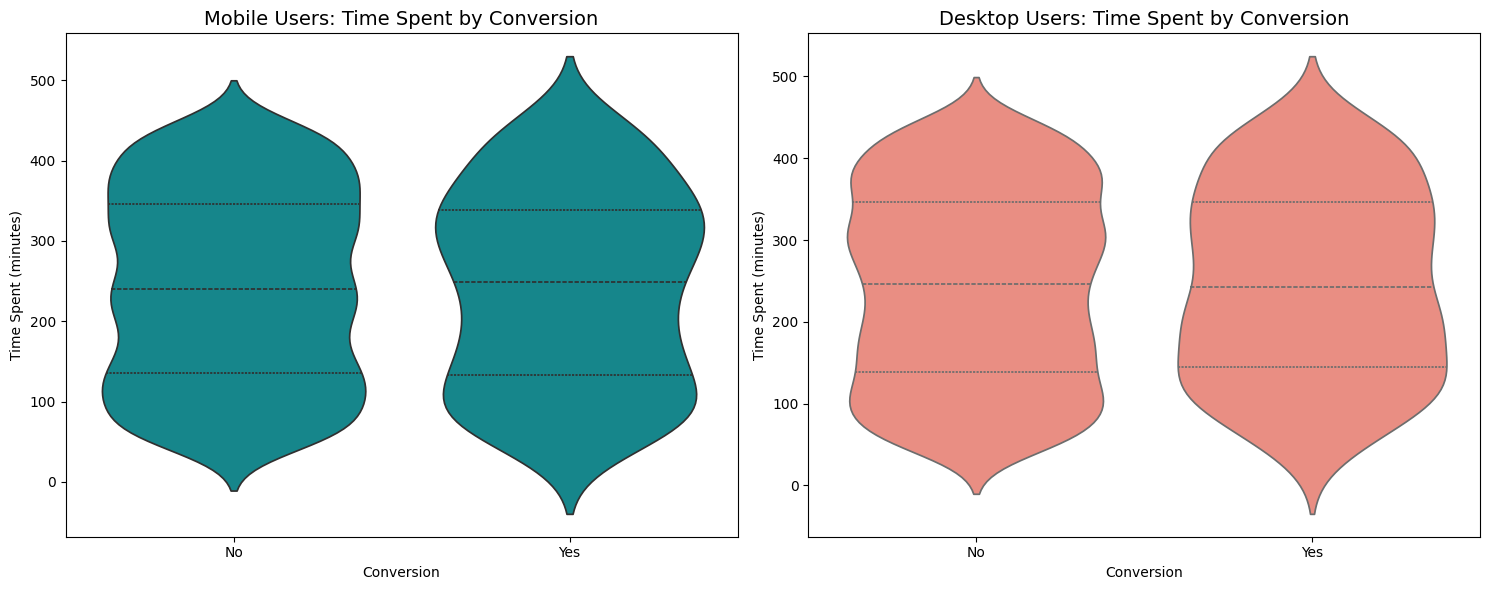

In [22]:
# how much time spend is there that generate conversion or non conversion on mobile

mobile = df[df['Device'] == 'Mobile']
desktop = df[df['Device'] == 'Desktop']


plt.figure(figsize=(15, 6))
# --- LEFT PLOT: Mobile ---
plt.subplot(1, 2, 1)
sns.violinplot(
    x='Conversion', 
    y='Time Spent', 
    data=mobile, 
    color='#03989E', 
    inner='quartile'  # Shows median and quartiles inside the violin
)
plt.title('Mobile Users: Time Spent by Conversion', fontsize=14)
plt.xlabel('Conversion')
plt.ylabel('Time Spent (minutes)')

# --- RIGHT PLOT: Desktop ---
plt.subplot(1, 2, 2)  # <-- FIXED: Correct subplot index (1,2,2)
sns.violinplot(
    x='Conversion', 
    y='Time Spent', 
    data=desktop, 
    color='salmon', 
    inner='quartile'
)
plt.title('Desktop Users: Time Spent by Conversion', fontsize=14)
plt.xlabel('Conversion')
plt.ylabel('Time Spent (minutes)')

plt.tight_layout()
plt.show()

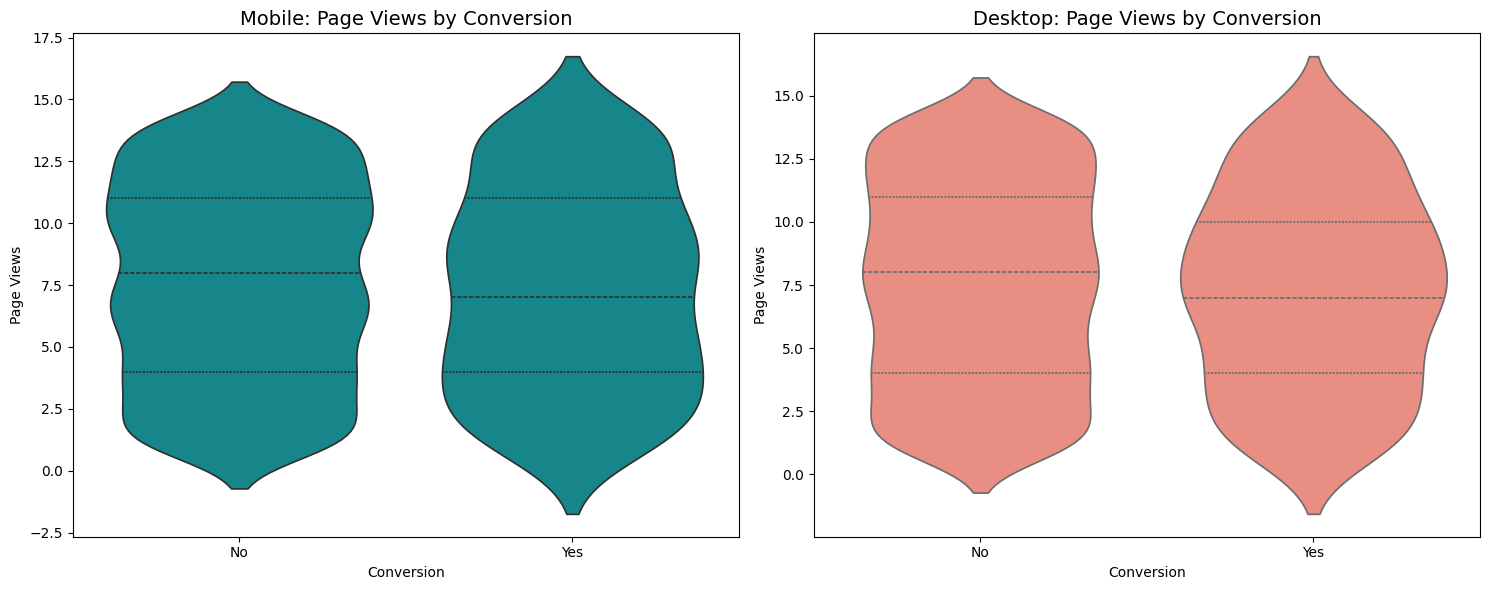

In [23]:
plt.figure(figsize=(15, 6))

# --- LEFT PLOT: Mobile ---
plt.subplot(1, 2, 1)
sns.violinplot(
    x='Conversion', 
    y='Page Views', 
    data=mobile, 
    color='#03989E', 
    inner='quartile'
)
plt.title('Mobile: Page Views by Conversion', fontsize=14)
plt.xlabel('Conversion')
plt.ylabel('Page Views')

# --- RIGHT PLOT: Desktop ---
plt.subplot(1, 2, 2)
sns.violinplot(
    x='Conversion', 
    y='Page Views', 
    data=desktop, 
    color='salmon', 
    inner='quartile'
)
plt.title('Desktop: Page Views by Conversion', fontsize=14)
plt.xlabel('Conversion')
plt.ylabel('Page Views')

plt.tight_layout()
plt.show()

Median is almost the same, quartile are also almost the same, and graphs are mostly overlapping.
- There is no such significance
- user who spent more time or less time does not show any pattern for conversion

In [24]:
mobile_converted = mobile[mobile['Conversion'].str.lower() == 'yes']
mobile_group = mobile_converted['Group'].value_counts()
desktop_converted = desktop[desktop['Conversion'].str.lower() == 'yes']
desktop_group = desktop_converted['Group'].value_counts()
desktop_group

Group
B    180
A     73
Name: count, dtype: int64

In [25]:
mobile_group

Group
B    169
A     63
Name: count, dtype: int64

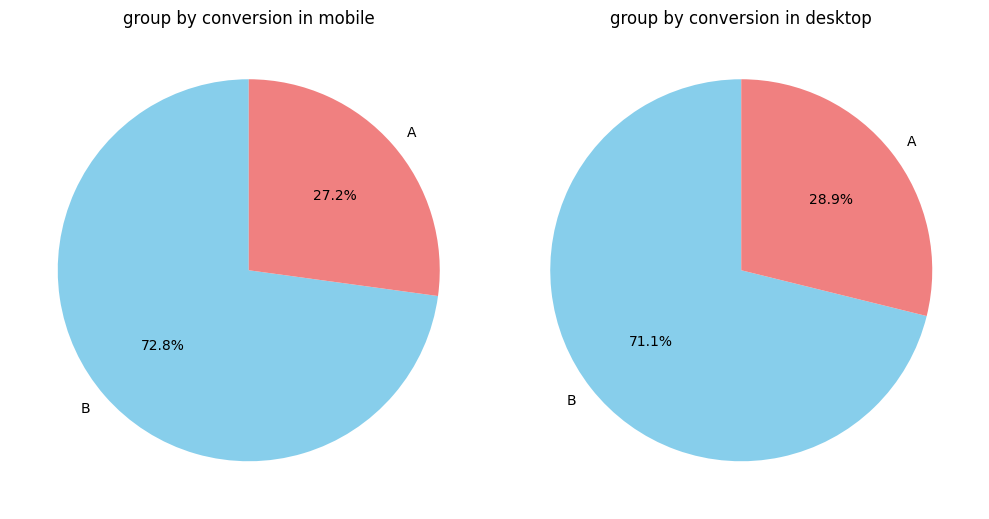

In [26]:
fig, ax = plt.subplots(1, 2, figsize= (10, 6))

ax[0].pie(mobile_group, labels= mobile_group.index, autopct = '%1.1f%%',startangle=90, colors=['skyblue', 'lightcoral'])
ax[0].set_title('group by conversion in mobile')

ax[1].pie(desktop_group, labels= desktop_group.index, autopct = '%1.1f%%',startangle=90, colors=['skyblue', 'lightcoral'])
ax[1].set_title('group by conversion in desktop')

plt.tight_layout()
plt.show()

Above pie chart is only showing the conversion which is YES, and group wise we can see which perticular group is showing better conversion.   

As the conversion data is in Yes/No, **Logistic Regression** will be best for the analysis.
### *Does Dark Theme really convert more?*

In [27]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [28]:
# for better visibility we made yes as 1 and no as 0
df['Conversion'] = df['Conversion'].map({'Yes': 1, 'No': 0})

In [29]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,0,Mobile,Northern Ireland
1,11682,A,9,342,0,Mobile,Scotland
2,19825,A,2,396,0,Desktop,Northern Ireland
3,16080,B,4,318,0,Desktop,Wales
4,18851,A,1,338,1,Desktop,Scotland


In [30]:
# split that data in dependent and independent groups
x = df.drop(['Conversion', 'User ID'], axis=1)
y = df['Conversion']

In [31]:
y

0       0
1       0
2       0
3       0
4       1
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: Conversion, Length: 5000, dtype: int64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [35]:
classifier = LogisticRegression()

In [46]:
parameter = {
    'penalty':['l1', 'l2', 'elasticnet'],
    'C':[1, 2, 3, 4, 5, 6, 7, 8, 12, 16,22, 28, 40], 
    'max_iter':[100, 200, 300],
    'solver': ['saga'], 
    'l1_ratio': [0.5] 
}

classifier_regression = GridSearchCV(classifier, param_grid= parameter, scoring= 'accuracy', cv= 5)

In [47]:
classifier_regression.fit(X_train, y_train)

ValueError: 
All the 585 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
117 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dewang\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dewang\anaconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Dewang\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        accept_large_sparse=solver not in ["liblinear", "sag", "saga"],
    

In [48]:
print(X_train.dtypes)

Group           str
Page Views    int64
Time Spent    int64
Device          str
Location        str
dtype: object


In [49]:
pd.get_dummies()

TypeError: get_dummies() missing 1 required positional argument: 'data'